In [2]:

import os
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    !pip install --no-deps bitsandbytes accelerate xformers==0.0.29.post3 peft trl==0.15.2 triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf datasets huggingface_hub hf_transfer
    !pip install --no-deps unsloth

In [3]:
import torch
import torch.nn as nn
import numpy as np
from unsloth import FastLanguageModel, UnslothTrainer
from transformers import TrainingArguments, DataCollatorForLanguageModeling, TextStreamer
from datasets import load_dataset
from datetime import datetime
import matplotlib.pyplot as plt

os.environ['UNSLOTH_RETURN_LOGITS'] = '1'
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Failed to patch Gemma3ForConditionalGeneration.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [4]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Llama-3.2-1B-bnb-4bit",
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
)

# Apply LoRA
model = FastLanguageModel.get_peft_model(
    model,
    r=64,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj",
                    "embed_tokens", "lm_head"],
    lora_alpha=32,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
    use_rslora=True,
)

==((====))==  Unsloth 2025.3.19: Fast Llama patching. Transformers: 4.51.1.
   \\   /|    NVIDIA A10G. Num GPUs = 1. Max memory: 22.191 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.6. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.29.post3. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Offloading input_embeddings to disk to save VRAM
Unsloth: Offloading output_embeddings to disk to save VRAM


Unsloth 2025.3.19 patched 16 layers with 16 QKV layers, 16 O layers and 16 MLP layers.


Unsloth: Training embed_tokens in mixed precision to save VRAM
Unsloth: Training lm_head in mixed precision to save VRAM


In [5]:
dataset = load_dataset("open-web-math/open-web-math", split="train[:14500]")  # 14,000 train + 500 val
EOS_TOKEN = tokenizer.eos_token

# Split into train and validation
train_dataset = dataset.select(range(14000))
val_dataset = dataset.select(range(14000, 14100))

def format_example(examples):
    return {"text": [ex + EOS_TOKEN for ex in examples["text"]]}

train_dataset = train_dataset.map(format_example, batched=True)
val_dataset = val_dataset.map(format_example, batched=True)

def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=2048)

tokenized_train = train_dataset.map(tokenize, batched=True)
tokenized_val = val_dataset.map(tokenize, batched=True)

Resolving data files:   0%|          | 0/114 [00:00<?, ?it/s]

In [6]:
class CustomTrainer(UnslothTrainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        logic_words = ["because", "therefore", "hence", "implies", "at least one"]
        token_ids = set()
        for word in logic_words:
            tokens = tokenizer.tokenize(word)
            ids = tokenizer.convert_tokens_to_ids(tokens)
            token_ids.update(ids)

        logic_mask = torch.zeros_like(labels, dtype=torch.float)
        for tid in token_ids:
            logic_mask += (labels == tid).float()

        α = 5.0
        soft_weights = 1.0 + torch.sigmoid(α * (logic_mask - 0.5)).to(labels.device)

        ce_loss = nn.CrossEntropyLoss(reduction="none")
        loss = ce_loss(logits.view(-1, logits.size(-1)), labels.view(-1))
        loss = loss * soft_weights.view(-1)
        loss = loss.mean()

        return (loss, outputs) if return_outputs else loss

In [7]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,
    learning_rate=5e-5,
    num_train_epochs=1,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    logging_steps=5,
    save_steps=100,
    save_total_limit=1,
    fp16=False,
    bf16=torch.cuda.is_bf16_supported(),
    report_to="none",
)

data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

In [8]:
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,  # Will be updated in loop
    tokenizer=tokenizer,
    data_collator=data_collator,
)

In [9]:
import gc
def compute_perplexity(model, dataset, batch_size=1):  # Reduced batch_size to 1
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    
    # Clear GPU memory before validation
    torch.cuda.empty_cache()
    gc.collect()
    
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        inputs = tokenizer(
            batch["text"],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=2048
        ).to(model.device)
        labels = inputs["input_ids"].clone()
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            loss = nn.CrossEntropyLoss(reduction="sum")(
                logits.view(-1, logits.size(-1)), labels.view(-1)
            )
            total_loss += loss.item()
            total_tokens += labels.numel()
        
        # Clear memory after each batch
        del inputs, labels, outputs, logits
        torch.cuda.empty_cache()
    
    perplexity = np.exp(total_loss / total_tokens)
    return perplexity

In [10]:
def count_reasoning_keywords(text, keywords=["because", "therefore", "hence", "implies"]):
    return sum(text.lower().count(kw) for kw in keywords)


def evaluate(model, tokenizer, prompts, round_num):
    FastLanguageModel.for_inference(model)
    streamer = TextStreamer(tokenizer)
    results = []
    for prompt in prompts:
        print(f"\n🧠 Prompt: {prompt}")
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=80,
                do_sample=False,
                temperature=0.7,
                streamer=streamer,
            )
        generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        keyword_count = count_reasoning_keywords(generated_text)
        results.append({"prompt": prompt, "output": generated_text, "keyword_count": keyword_count})
        # Clear memory after each generation
        del inputs, outputs
        torch.cuda.empty_cache()
    return results

In [11]:
torch.cuda.empty_cache()
gc.collect()
torch.cuda.reset_peak_memory_stats()
print(f"Memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GiB")
print(f"Memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GiB")

Memory allocated: 1.63 GiB
Memory reserved: 1.65 GiB


In [12]:
!nvidia-smi

Tue Apr 22 15:10:15 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.247.01             Driver Version: 535.247.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA A10G                    Off | 00000000:00:1E.0 Off |                    0 |
|  0%   35C    P0              65W / 300W |   2004MiB / 23028MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [13]:
num_rounds = 3
samples_per_round = 2000
eval_prompts = [
    "If x is greater than 5 and y is less than x, therefore",
    "Given that all primes greater than 2 are odd, it follows that",
    "If a triangle is isosceles, then it implies",
]
train_losses = []
val_perplexities = []
keyword_counts = []

for round_num in range(num_rounds):
    start = round_num * samples_per_round
    end = min(start + samples_per_round, len(tokenized_train))
    print(f"\n🚀 Starting training round {round_num + 1} | Samples {start} to {end}")

    # Slice dataset
    dataset_slice = tokenized_train.select(range(start, end))
    trainer.train_dataset = dataset_slice

    # Train
    train_result = trainer.train()
    train_loss = train_result.training_loss
    train_losses.append(train_loss)

    # Clear memory before validation
    torch.cuda.empty_cache()
    gc.collect()

    # Compute validation perplexity
    val_perplexity = compute_perplexity(model, tokenized_val)
    val_perplexities.append(val_perplexity)
    print(f"📊 Validation Perplexity: {val_perplexity:.2f}")

    # Save checkpoint
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_dir = f"checkpoints/lora_round_{round_num+1}_{timestamp}"
    os.makedirs(model_dir, exist_ok=True)
    model.save_pretrained(model_dir)
    tokenizer.save_pretrained(model_dir)
    print(f"✅ Saved model to {model_dir}")

    # Evaluate
    eval_results = evaluate(model, tokenizer, eval_prompts, round_num)
    avg_keyword_count = np.mean([r["keyword_count"] for r in eval_results])
    keyword_counts.append(avg_keyword_count)
    print(f"🔍 Average Reasoning Keyword Count: {avg_keyword_count:.2f}")


🚀 Starting training round 1 | Samples 0 to 2000


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,000 | Num Epochs = 1 | Total steps = 62
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 8 x 1) = 32
 "-____-"     Trainable parameters = 570,425,344/1,000,000,000 (57.04% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
5,52.346300
10,35.098100
15,13.929600
20,4.057900
25,0.700200
30,0.117200
35,0.059100
40,0.047600
45,0.045200
50,0.042000


📊 Validation Perplexity: 1.01
✅ Saved model to checkpoints/lora_round_1_20250422_152315

🧠 Prompt: If x is greater than 5 and y is less than x, therefore
<|begin_of_text|>If x is greater than 5 and y is less than x, therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore ther

...

Step,Training Loss
5,0.039600
10,0.035100
15,0.024400
20,0.013500
25,0.004500
30,0.001600
35,0.001100
40,0.001200
45,0.000800
50,0.001000


📊 Validation Perplexity: 1.00
✅ Saved model to checkpoints/lora_round_2_20250422_153622

🧠 Prompt: If x is greater than 5 and y is less than x, therefore
<|begin_of_text|>If x is greater than 5 and y is less than x, therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore ther

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,000 | Num Epochs = 1 | Total steps = 62
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 8 x 1) = 32
 "-____-"     Trainable parameters = 570,425,344/1,000,000,000 (57.04% trained)


Step,Training Loss
5,0.001000
10,0.001000
15,0.000600
20,0.000700
25,0.000500
30,0.000500
35,0.000600
40,0.000500
45,0.002800
50,0.000700


📊 Validation Perplexity: 1.00
✅ Saved model to checkpoints/lora_round_3_20250422_154928

🧠 Prompt: If x is greater than 5 and y is less than x, therefore
<|begin_of_text|>If x is greater than 5 and y is less than x, therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore therefore ther

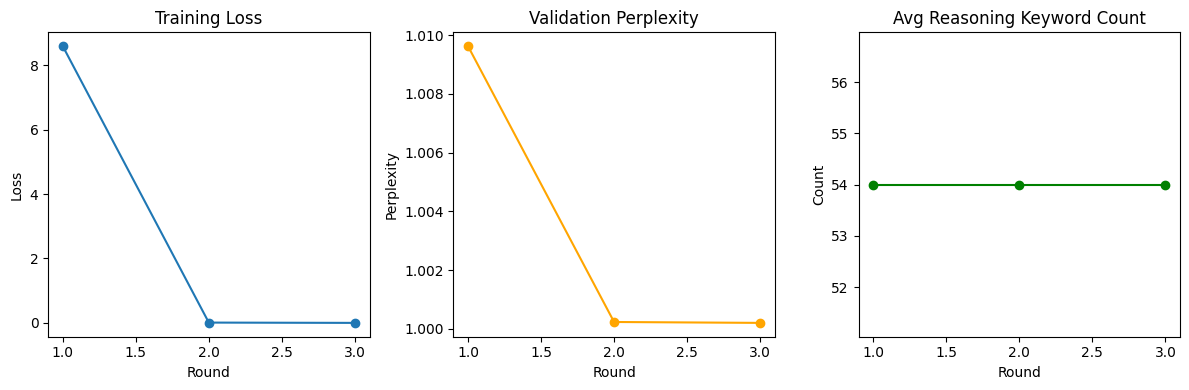

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(range(1, num_rounds+1), train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Round")
plt.ylabel("Loss")

plt.subplot(1, 3, 2)
plt.plot(range(1, num_rounds+1), val_perplexities, marker='o', color='orange')
plt.title("Validation Perplexity")
plt.xlabel("Round")
plt.ylabel("Perplexity")

plt.subplot(1, 3, 3)
plt.plot(range(1, num_rounds+1), keyword_counts, marker='o', color='green')
plt.title("Avg Reasoning Keyword Count")
plt.xlabel("Round")
plt.ylabel("Count")

plt.tight_layout()
plt.show()